In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from imblearn.over_sampling import SMOTE

from sklearn.preprocessing import OneHotEncoder,StandardScaler,OrdinalEncoder

from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import PowerTransformer


from sklearn.metrics import accuracy_score,classification_report,roc_auc_score,roc_curve



In [3]:
data=pd.read_csv('loan_data_set.csv')
data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [4]:
data.shape

(614, 13)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [6]:
data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [7]:
(np.sum(data.isnull())/len(data))*100

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


,0
Loan_ID,0.000000
Gender,2.117264
Married,0.488599
Dependents,2.442997
Education,0.000000
Self_Employed,5.211726
ApplicantIncome,0.000000
CoapplicantIncome,0.000000
LoanAmount,3.583062
Loan_Amount_Term,2.280130


In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
corr=data.corr(numeric_only=True)
corr

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
ApplicantIncome,1.000000,-0.116605,0.570909,-0.045306,-0.014715
CoapplicantIncome,-0.116605,1.000000,0.188619,-0.059878,-0.002056
LoanAmount,0.570909,0.188619,1.000000,0.039447,-0.008433
Loan_Amount_Term,-0.045306,-0.059878,0.039447,1.000000,0.001470
Credit_History,-0.014715,-0.002056,-0.008433,0.001470,1.000000


<Axes: >

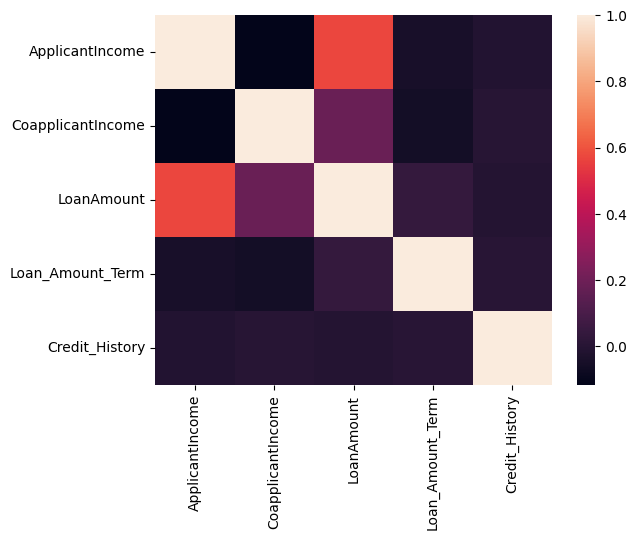

In [10]:
sns.heatmap(corr)

In [11]:
data.drop(columns=['Loan_ID'],inplace=True)

In [12]:
data

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [13]:
data.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [14]:
cat=['Gender', 'Married','Education', 'Self_Employed','Property_Area']
num=['Dependents','ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History']

In [15]:
data['Gender'].value_counts()


,count
Gender,
Male,489
Female,112


In [16]:
data['Married'].value_counts()


,count
Married,
Yes,398
No,213


In [17]:
data['Education'].value_counts()

,count
Education,
Graduate,480
Not Graduate,134


In [18]:
data['Self_Employed'].value_counts()

,count
Self_Employed,
No,500
Yes,82


In [19]:
data['Property_Area'].value_counts()

,count
Property_Area,
Semiurban,233
Urban,202
Rural,179


# EDA

# Univariate Analysis

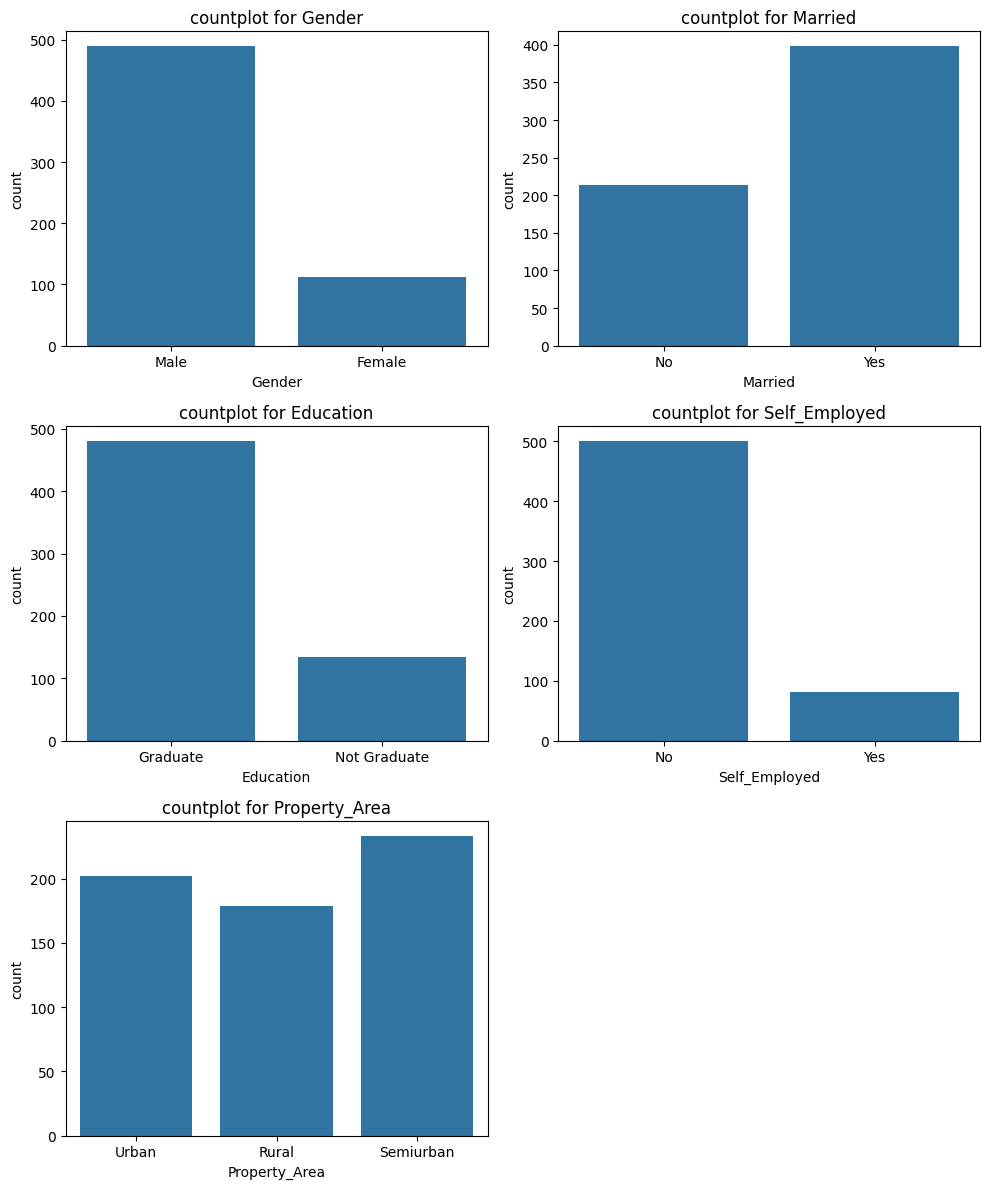

In [20]:
cat=['Gender', 'Married','Education', 'Self_Employed','Property_Area']

plt.figure(figsize=(10,12))
for index, col in enumerate(cat):

  plt.subplot(3,2,index+1)

  sns.countplot(x=col, data=data)
  plt.title(f'countplot for {col}')
  plt.xlabel(col)
  plt.ylabel('count')
  plt.tight_layout()
plt.show()

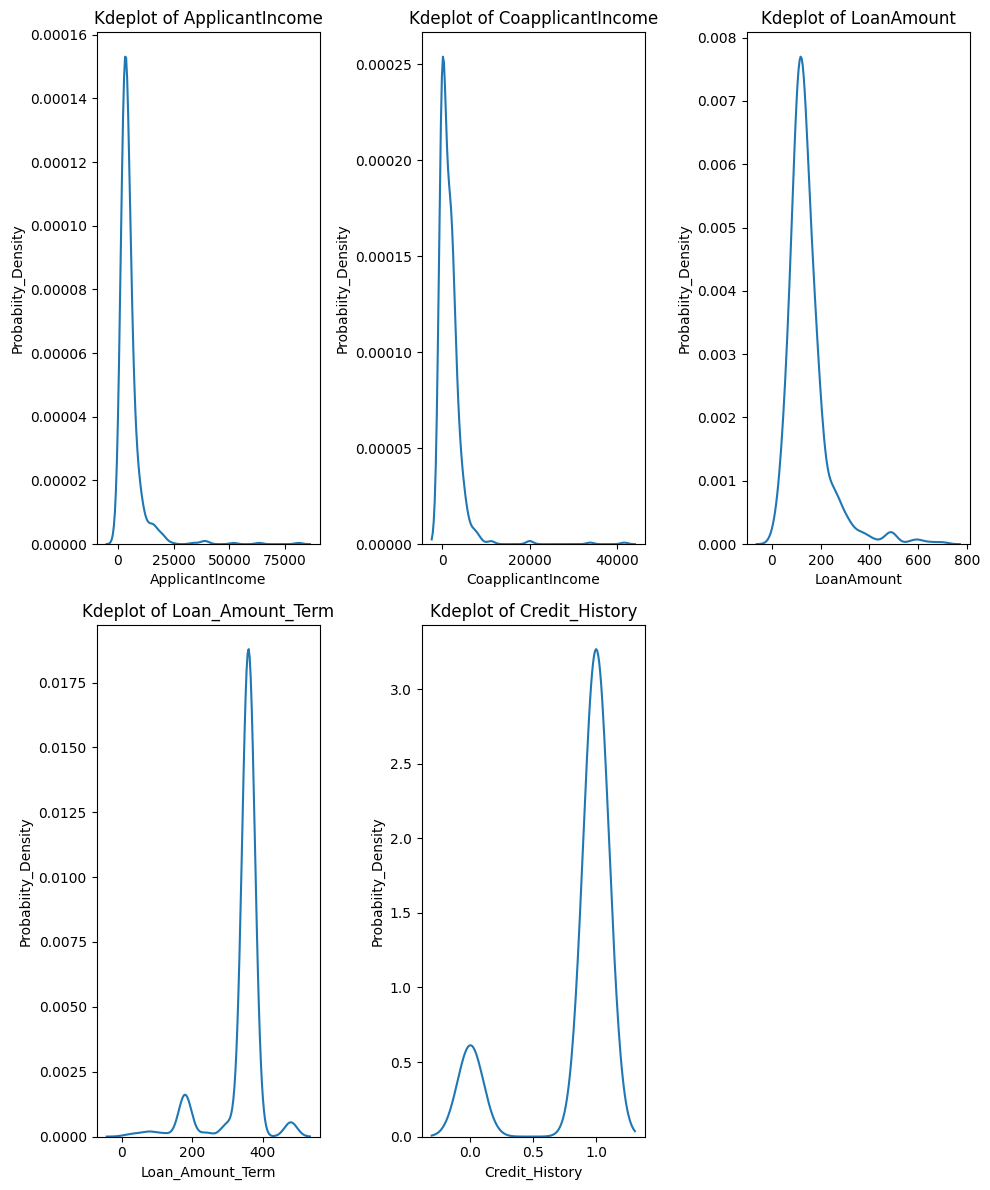

In [21]:
num=['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History']

plt.figure(figsize=(10,12))

for index,col in enumerate(num):

  plt.subplot(2,3,index+1)
  sns.kdeplot(x=col,data=data)
  plt.title(f'Kdeplot of {col}')
  plt.xlabel(col)
  plt.ylabel('Probabiity_Density')
  plt.tight_layout()

plt.show()

In [22]:
for i in num:
  print(data[num].skew().sort_values(ascending=False))

CoapplicantIncome    7.491531
ApplicantIncome      6.539513
LoanAmount           2.677552
Credit_History      -1.882361
Loan_Amount_Term    -2.362414
dtype: float64
CoapplicantIncome    7.491531
ApplicantIncome      6.539513
LoanAmount           2.677552
Credit_History      -1.882361
Loan_Amount_Term    -2.362414
dtype: float64
CoapplicantIncome    7.491531
ApplicantIncome      6.539513
LoanAmount           2.677552
Credit_History      -1.882361
Loan_Amount_Term    -2.362414
dtype: float64
CoapplicantIncome    7.491531
ApplicantIncome      6.539513
LoanAmount           2.677552
Credit_History      -1.882361
Loan_Amount_Term    -2.362414
dtype: float64
CoapplicantIncome    7.491531
ApplicantIncome      6.539513
LoanAmount           2.677552
Credit_History      -1.882361
Loan_Amount_Term    -2.362414
dtype: float64


<Axes: xlabel='count', ylabel='Loan_Status'>

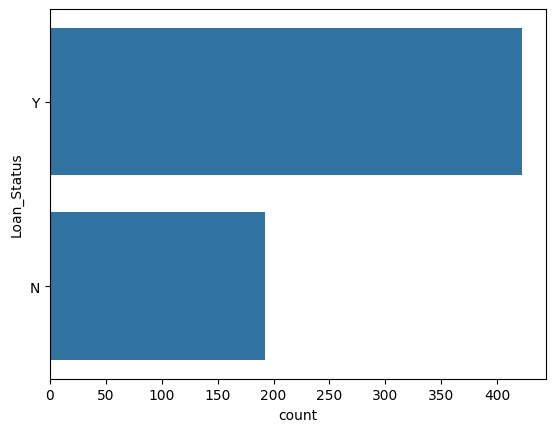

In [23]:
sns.countplot(data['Loan_Status'])

# Bivariate Analysis

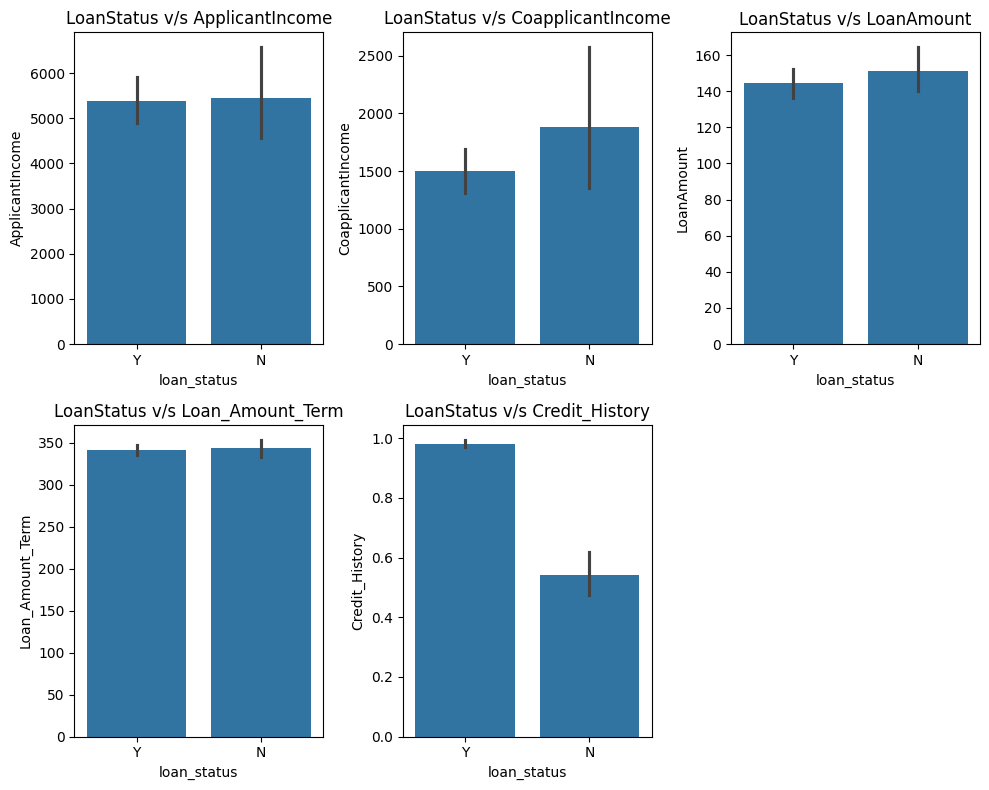

In [24]:
plt.figure(figsize=(10,8))

for index,col in enumerate(num):
  plt.subplot(2,3,index+1)
  sns.barplot(x='Loan_Status',y=col,data=data)
  plt.title(f'LoanStatus v/s {col}')
  plt.xlabel('loan_status')
  plt.ylabel(col)
  plt.tight_layout()

plt.show()

In [25]:
data['Dependents'].value_counts()

,count
Dependents,
0,345
1,102
2,101
3+,51


In [26]:
data['Dependents'] = data['Dependents'].fillna('0')
data['Dependents'] = data['Dependents'].replace('3+', '3').astype(int)

In [27]:
def new_dependent(num):
  if num==0:
    return 'Single'
  elif num==1 or num==2:
    return 'Nuclear family'
  else:
    return 'Large family'

In [28]:
data['Dependents']=data['Dependents'].apply(new_dependent)

In [29]:
data['Dependents']

,Dependents
0,Single
1,Nuclear family
2,Single
3,Single
4,Single
...,...
609,Single
610,Large family
611,Nuclear family
612,Nuclear family


In [30]:
data['Dependents'].value_counts()

,count
Dependents,
Single,360
Nuclear family,203
Large family,51


In [31]:
data['Loan_Status'].value_counts()

,count
Loan_Status,
Y,422
N,192


In [32]:
def convert_output(num):
  if num=='Y':
    return 1
  elif num=='N' :
    return 0
  else:
    return 'invalid'

In [33]:
data['Total_Income']=data['ApplicantIncome']+data['CoapplicantIncome']

In [34]:
data['Income_Loan_Ratio']=data['Total_Income'] / data['LoanAmount']

In [35]:
data['Loan_Status']=data['Loan_Status'].apply(convert_output)

In [36]:
data['Loan_Status']

,Loan_Status
0,1
1,0
2,1
3,1
4,1
...,...
609,1
610,1
611,1
612,1


In [37]:
data['Loan_Status'].value_counts()

,count
Loan_Status,
1,422
0,192


In [38]:
data.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'Total_Income', 'Income_Loan_Ratio'],
      dtype='object')

![image.png](
  
)

In [39]:
data.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'Total_Income', 'Income_Loan_Ratio'],
      dtype='object')

In [40]:
trf2=StandardScaler()

In [41]:
data

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,Income_Loan_Ratio
0,Male,No,Single,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,1,5849.0,NaN
1,Male,Yes,Nuclear family,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0,6091.0,47.585938
2,Male,Yes,Single,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1,3000.0,45.454545
3,Male,Yes,Single,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1,4941.0,41.175000
4,Male,No,Single,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1,6000.0,42.553191
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,Single,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,1,2900.0,40.845070
610,Male,Yes,Large family,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,1,4106.0,102.650000
611,Male,Yes,Nuclear family,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,1,8312.0,32.853755
612,Male,Yes,Nuclear family,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,1,7583.0,40.550802


<Axes: xlabel='Dependents', ylabel='Loan_Status'>

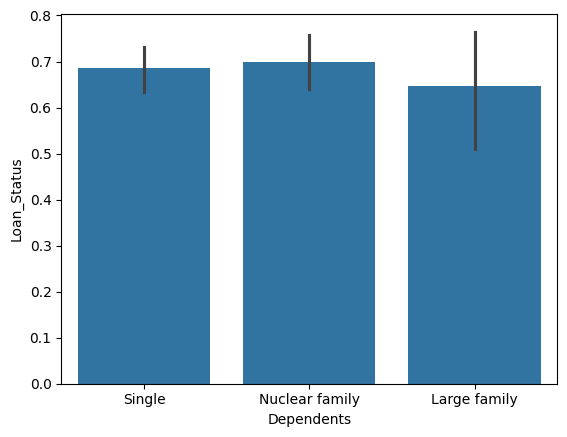

In [42]:
sns.barplot(x=data['Dependents'],y=data['Loan_Status'])

In [43]:
x=data.drop(columns=['Loan_Status'])
x

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Total_Income,Income_Loan_Ratio
0,Male,No,Single,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,5849.0,NaN
1,Male,Yes,Nuclear family,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,6091.0,47.585938
2,Male,Yes,Single,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,3000.0,45.454545
3,Male,Yes,Single,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,4941.0,41.175000
4,Male,No,Single,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,6000.0,42.553191
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,Single,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,2900.0,40.845070
610,Male,Yes,Large family,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,4106.0,102.650000
611,Male,Yes,Nuclear family,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,8312.0,32.853755
612,Male,Yes,Nuclear family,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,7583.0,40.550802


In [44]:
y=data['Loan_Status']
y

,Loan_Status
0,1
1,0
2,1
3,1
4,1
...,...
609,1
610,1
611,1
612,1


In [45]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [46]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Feature groups
cat_ohe = ['Gender', 'Married', 'Self_Employed','Education', 'Property_Area']
cat_ordinal = ['Dependents']
num_mean = ['LoanAmount']
num_freq = ['Loan_Amount_Term', 'Credit_History','Income_Loan_Ratio']
num_scale = ['ApplicantIncome', 'CoapplicantIncome','Total_Income']

# Encoder categories for ordinal features
ordinal_categories = [
    ['Single', 'Nuclear family', 'Large family']
]

# ColumnTransformer combining everything
preprocessor = ColumnTransformer(
    transformers=[
        ('cat_ohe', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_ohe),

        ('cat_ordinal', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OrdinalEncoder(categories=ordinal_categories))
        ]), cat_ordinal),

        ('num_mean', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('power_trf',PowerTransformer(method='yeo-johnson'))
        ]), num_mean),

        ('num_freq', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('power_trf',PowerTransformer(method='yeo-johnson'))
        ]), num_freq),

        ('num_scale', Pipeline([
            ('scaler', StandardScaler()),
            ('power_trf',PowerTransformer(method='yeo-johnson'))
        ]), num_scale)
    ],
    remainder='passthrough'
)


In [47]:
pipe1=ImbPipeline([
    ('trf1',preprocessor),
    ('smote',SMOTE(random_state=42)),
    ('lr',LogisticRegression())
])

In [48]:
pipe1.fit(x_train,y_train)

Pipeline(steps=[('trf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat_ohe',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Married',
                                                   'Self_Employed', 'Education',
                                                   'Property_Area']),
                                                 ('cat_ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_f...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('power_trf',
                                                                   PowerTransformer())]),
                                                  ['Loan_Amount_Term',
                                                   'Credit_History',
                                                   'Income_Loan_Ratio']),
                                                 ('num_scale',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler()),
                                                                  ('power_trf',
                                                                   PowerTransformer())]),
                                                  ['ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'Total_Income'])])),
                ('smote', SMOTE(random_state=42)),
                ('lr', LogisticRegression())])

In [49]:
y_pred=pipe1.predict(x_test)

In [50]:
print("Accuracy: ",accuracy_score(y_test,y_pred))

Accuracy:  0.7560975609756098


In [51]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.70      0.53      0.61        43
           1       0.78      0.88      0.82        80

    accuracy                           0.76       123
   macro avg       0.74      0.70      0.71       123
weighted avg       0.75      0.76      0.75       123



In [52]:
pipe2=Pipeline([
    ('trf1',preprocessor),
    ('lr',RandomForestClassifier())
])

In [53]:
pipe2.fit(x_train,y_train)

Pipeline(steps=[('trf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat_ohe',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Married',
                                                   'Self_Employed', 'Education',
                                                   'Property_Area']),
                                                 ('cat_ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_f...
                                                 ('num_freq',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('power_trf',
                                                                   PowerTransformer())]),
                                                  ['Loan_Amount_Term',
                                                   'Credit_History',
                                                   'Income_Loan_Ratio']),
                                                 ('num_scale',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler()),
                                                                  ('power_trf',
                                                                   PowerTransformer())]),
                                                  ['ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'Total_Income'])])),
                ('lr', RandomForestClassifier())])

In [54]:
y_pred2=pipe2.predict(x_test)

In [55]:
print("Accuracy: ",accuracy_score(y_test,y_pred2))

Accuracy:  0.8130081300813008


In [56]:
print(classification_report(y_test,y_pred2))

              precision    recall  f1-score   support

           0       0.95      0.49      0.65        43
           1       0.78      0.99      0.87        80

    accuracy                           0.81       123
   macro avg       0.87      0.74      0.76       123
weighted avg       0.84      0.81      0.79       123



In [57]:
pipe3=Pipeline([
    ('trf1',preprocessor),
    ('gb',GradientBoostingClassifier())
])

In [58]:
pipe3.fit(x_train,y_train)

Pipeline(steps=[('trf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat_ohe',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Married',
                                                   'Self_Employed', 'Education',
                                                   'Property_Area']),
                                                 ('cat_ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_f...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('power_trf',
                                                                   PowerTransformer())]),
                                                  ['Loan_Amount_Term',
                                                   'Credit_History',
                                                   'Income_Loan_Ratio']),
                                                 ('num_scale',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler()),
                                                                  ('power_trf',
                                                                   PowerTransformer())]),
                                                  ['ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'Total_Income'])])),
                ('gb', GradientBoostingClassifier())])

In [59]:
y_pred3=pipe3.predict(x_test)

In [60]:
print("Accuracy: ",accuracy_score(y_test,y_pred3))

Accuracy:  0.7723577235772358


In [61]:
print(classification_report(y_test,y_pred3))

              precision    recall  f1-score   support

           0       0.80      0.47      0.59        43
           1       0.77      0.94      0.84        80

    accuracy                           0.77       123
   macro avg       0.78      0.70      0.72       123
weighted avg       0.78      0.77      0.75       123



In [62]:
pipe4=Pipeline([
    ('trf1',preprocessor),
    ('gb',XGBClassifier())
])

In [63]:
pipe4.fit(x_train,y_train)

Pipeline(steps=[('trf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat_ohe',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Married',
                                                   'Self_Employed', 'Education',
                                                   'Property_Area']),
                                                 ('cat_ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_f...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [64]:
y_pred4=pipe4.predict(x_test)

In [65]:
print("Accuracy: ",accuracy_score(y_test,y_pred4))

Accuracy:  0.7560975609756098


In [66]:
print(classification_report(y_test,y_pred4))

              precision    recall  f1-score   support

           0       0.71      0.51      0.59        43
           1       0.77      0.89      0.83        80

    accuracy                           0.76       123
   macro avg       0.74      0.70      0.71       123
weighted avg       0.75      0.76      0.74       123



In [67]:
from sklearn.tree import DecisionTreeClassifier
pipe5=Pipeline([
    ('trf1',preprocessor),
    ('dt',DecisionTreeClassifier())
])

In [68]:
pipe5.fit(x_train,y_train)

Pipeline(steps=[('trf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat_ohe',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Married',
                                                   'Self_Employed', 'Education',
                                                   'Property_Area']),
                                                 ('cat_ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_f...
                                                 ('num_freq',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('power_trf',
                                                                   PowerTransformer())]),
                                                  ['Loan_Amount_Term',
                                                   'Credit_History',
                                                   'Income_Loan_Ratio']),
                                                 ('num_scale',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler()),
                                                                  ('power_trf',
                                                                   PowerTransformer())]),
                                                  ['ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'Total_Income'])])),
                ('dt', DecisionTreeClassifier())])

In [69]:
y_pred5=pipe5.predict(x_test)

In [70]:
print("Accuracy: ",accuracy_score(y_test,y_pred5))

Accuracy:  0.7398373983739838


In [71]:
# Install optuna if not already installed
!pip install optuna

import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, make_scorer
import numpy as np
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Objective function for Optuna
def objective(trial):
    # Suggest hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 100, 500)
    max_depth = trial.suggest_int('max_depth', 5, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])

    # Define the model within an ImbPipeline that includes preprocessing and SMOTE
    model_pipeline = ImbPipeline([
        ('trf1', preprocessor), # Apply the preprocessor
        ('smote', SMOTE(random_state=42)), # Apply SMOTE
        ('classifier', RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            random_state=42
        ))
    ])

    score = cross_val_score(model_pipeline, x_train, y_train, cv=3, scoring='accuracy').mean()

    return score


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.7/265.7 kB 17.2 MB/s eta 0:00:00


In [72]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("Best trial:")
trial = study.best_trial
print(trial.params)

[I 2026-08-08 13:11:11,528] A new study created in memory with name: no-name-b278f96e-2cfa-448c-803f-4fa52e8f99e4
[I 2026-08-08 13:11:13,463] Trial 0 finished with value: 0.7760362112823582 and parameters: {'n_estimators': 135, 'max_depth': 21, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': None}. Best is trial 0 with value: 0.7760362112823582.
[I 2026-08-08 13:11:14,707] Trial 1 finished with value: 0.7902763230086288 and parameters: {'n_estimators': 153, 'max_depth': 18, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 1 with value: 0.7902763230086288.
[I 2026-08-08 13:11:17,731] Trial 2 finished with value: 0.7617711606563918 and parameters: {'n_estimators': 478, 'max_depth': 6, 'min_samples_split': 16, 'min_samples_leaf': 8, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.7902763230086288.
[I 2026-08-08 13:11:20,228] Trial 3 finished with value: 0.7577185894558331 and parameters: {'n_estimators': 375, 'max_depth': 12, 'min

Best trial:
{'n_estimators': 363, 'max_depth': 27, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': None}


In [73]:
from sklearn.tree import DecisionTreeClassifier
from imblearn.pipeline import Pipeline as ImbPipeline # Ensure ImbPipeline is imported if it's used elsewhere
pipe6=ImbPipeline([
    ('trf1',preprocessor),
    ('rf',RandomForestClassifier(n_estimators= 409, max_depth= 13, min_samples_split= 6, min_samples_leaf=4, max_features=None, random_state=42))
])

In [74]:
pipe6.fit(x_train,y_train)

Pipeline(steps=[('trf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat_ohe',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Married',
                                                   'Self_Employed', 'Education',
                                                   'Property_Area']),
                                                 ('cat_ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_f...
                                                                   PowerTransformer())]),
                                                  ['Loan_Amount_Term',
                                                   'Credit_History',
                                                   'Income_Loan_Ratio']),
                                                 ('num_scale',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler()),
                                                                  ('power_trf',
                                                                   PowerTransformer())]),
                                                  ['ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'Total_Income'])])),
                ('rf',
                 RandomForestClassifier(max_depth=13, max_features=None,
                                        min_samples_leaf=4, min_samples_split=6,
                                        n_estimators=409, random_state=42))])

In [75]:
y_pred6=pipe6.predict(x_test)

In [76]:
print("Accuracy: ",accuracy_score(y_test,y_pred6))

Accuracy:  0.8130081300813008


# Random Forest(with hyperparmeter tuning) is giving better accuracy of 81


In [77]:
pipe6.named_steps['rf'].feature_importances_

array([0.00434409, 0.00332606, 0.00864718, 0.00979015, 0.0023498 ,
       0.00191667, 0.00638278, 0.00530305, 0.0164257 , 0.01523697,
       0.00556056, 0.01268324, 0.09159874, 0.02155524, 0.41230009,
       0.12777223, 0.09336364, 0.04155762, 0.11988618])

In [78]:
feature_names = preprocessor.get_feature_names_out()
importances = pipe6.named_steps['rf'].feature_importances_

feature_importances = pd.Series(importances, index=feature_names)

# Sort feature importances for better visualization
sorted_importances = feature_importances.sort_values(ascending=False)
display(sorted_importances)

,0
num_freq__Credit_History,0.412300
num_freq__Income_Loan_Ratio,0.127772
num_scale__Total_Income,0.119886
num_scale__ApplicantIncome,0.093364
num_mean__LoanAmount,0.091599
num_scale__CoapplicantIncome,0.041558
num_freq__Loan_Amount_Term,0.021555
cat_ohe__Property_Area_Rural,0.016426
cat_ohe__Property_Area_Semiurban,0.015237
cat_ordinal__Dependents,0.012683


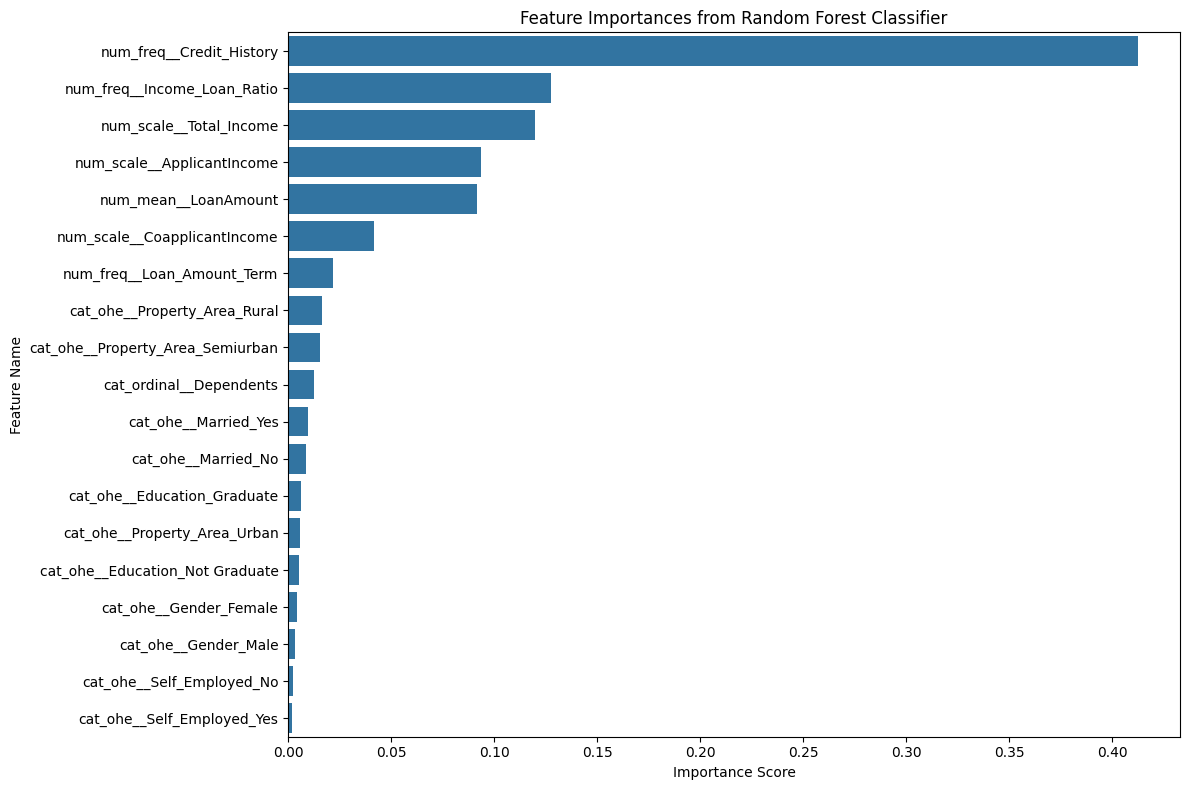

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.barplot(x=sorted_importances.values, y=sorted_importances.index)
plt.title('Feature Importances from Random Forest Classifier')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

In [80]:
y_proba = pipe6.predict_proba(x_test)[:, 1]

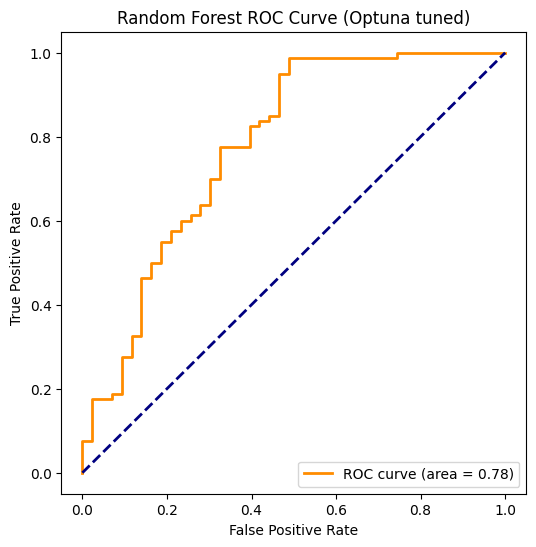

In [81]:
x=data.drop(columns=['Loan_Status'])
y=data['Loan_Status']
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)


plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve (Optuna tuned)')
plt.legend(loc="lower right")
plt.show()